# MVP — Machine Learning & Analytics
## Classificação de Cogumelos — Mushroom UCI

**Nome:** Thiago Gioso Fernandes   
**Data:** 16/06/2026  
**Dataset:** [UCI Mushroom — Agaricus Lepiota](https://archive.ics.uci.edu/dataset/73/mushroom)  
**Tipo de problema:** Classificação binária supervisionada  

---

## Observações importantes

Este notebook implementa um fluxo completo de Machine Learning para prever se um cogumelo é
**comestível (e)** ou **venenoso (p)** com base em 22 atributos categóricos físicos e ambientais.

> O dataset é carregado diretamente via URL pública — basta executar todas as células na ordem.

> **Atenção:** o custo do erro é **assimétrico**: classificar um cogumelo venenoso como comestível
> (Falso Negativo) é crítico (Não queremos ninguém morrendo). Por isso, **recall para a classe venenoso** é a métrica primária.

## Checklist do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☑ |
| Dataset descrito, com fonte, atributos e restrições | ☑ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☑ |
| Análise exploratória objetiva, conectada à modelagem | ☑ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☑ |
| Prevenção de vazamento de dados | ☑ |
| Tratamentos de dados justificados | ☑ |
| Pipeline ou sequência reprodutível de pré-processamento | ☑ |
| Modelo baseline definido | ☑ |
| Pelo menos dois modelos/abordagens comparados | ☑ |
| Ajuste de hiperparâmetros em pelo menos um modelo | ☑ |
| Avaliação com métricas coerentes com o problema | ☑ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☑ |
| Código limpo, organizado e executável do início ao fim | ☑ |
| Conclusão conectada ao objetivo inicial | ☑ |

> Todos os itens se aplicam a este problema de classificação binária supervisionada.

# 1. Definição do Problema

## 1.1 Descrição do problema

O consumo acidental de cogumelos venenosos é um risco real de saúde pública em diversas regiões
do mundo. O dataset **Mushroom** do UCI Repository contém 8.124 amostras de cogumelos da espécie
*Agaricus* e *Lepiota*, cada uma descrita por 22 atributos categóricos (forma do chapéu, cor,
odor, textura etc.) e rotulada como **comestível (e)** ou **venenosa (p)**.

**Contexto:** coletores de cogumelos, biólogos de campo e aplicativos de identificação de plantas
podem se beneficiar de um classificador automático confiável.

**Quem se beneficia:** qualquer pessoa que precise identificar a comestibilidade de um cogumelo a
partir de características visuais e sensoriais.

## 1.2 Objetivo do MVP

> O objetivo deste MVP é construir e avaliar modelos de Machine Learning para **prever se um
> cogumelo é comestível ou venenoso** a partir de seus 22 atributos categóricos, comparando uma
> solução baseline com modelos candidatos e discutindo limitações e erros críticos.

## 1.3 Tipo de problema

- **Tipo:** Classificação binária supervisionada  
- **Justificativa:** existe uma variável-alvo rotulada com duas categorias discretas (`e`/`p`),
  e o objetivo é aprender padrões nos atributos para prever a classe de novos exemplos.
- **Por que é ML:** há volume de dados suficiente para aprender regras não triviais
  (atributos como `odor` são altamente preditivos mas a relação com outras variáveis é complexa).

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. O odor do cogumelo é o atributo mais discriminativo entre as classes.
2. Uma combinação de atributos físicos permite classificação com alto recall para venenoso.
3. Modelos baseados em árvores devem superar regressão logística dada a natureza categórica dos dados.

**Critérios de sucesso:**
- **Métrica primária:** Recall para classe venenoso (p) — queremos minimizar Falsos Negativos.
- **Métrica secundária:** F1-score ponderado — equilíbrio geral entre precision e recall.
- **Resultado mínimo:** superar o baseline (most_frequent) em pelo menos 20 pp de recall para venenoso.
- **Restrição prática:** modelo interpretável é preferível (árvore de decisão) para auditabilidade.

**Custo assimétrico dos erros:**
| Erro | Consequência |
|---|---|
| FP (comestível previsto como venenoso) | Descarte desnecessário — baixo custo |
| FN (venenoso previsto como comestível) | Risco de intoxicação grave — **custo crítico** |

# 2. Ambiente, Bibliotecas e Reprodutibilidade



In [155]:
# === Setup básico e reprodutibilidade ===
import os, sys, time, random, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay
)
from scipy.stats import randint

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__, "| sklearn:", __import__('sklearn').__version__)
print("Seed fixada:", SEED)

Python: 3.12.13
pandas: 2.2.2 | sklearn: 1.6.1
Seed fixada: 42


## 2.1 Funções auxiliares

Funções reutilizáveis para avaliação de modelos

In [156]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_classification(name, y_true, y_pred, proba=None):
    """Retorna um dicionário com métricas de classificação."""

    res = {
        "accuracy": round(accuracy_score(y_true, y_pred), 4),

        "precision_ven": round(
            precision_score(y_true, y_pred, pos_label='p'),
            4
        ),

        "recall_ven": round(
            recall_score(y_true, y_pred, pos_label='p'),
            4
        ),

        "f1_ponderado": round(
            f1_score(y_true, y_pred, average="weighted"),
            4
        )
    }

    if proba is not None:
        try:
            y_bin = (y_true == "p").astype(int)

            # Assume que a classe "p" está na segunda coluna
            res["roc_auc"] = round(
                roc_auc_score(y_bin, proba[:, 1]),
                4
            )
        except Exception:
            res["roc_auc"] = float("nan")

    return res


def show_results(results_dict):
    return (
        pd.DataFrame(results_dict)
        .T
        .sort_values("recall_ven", ascending=False)
    )

# 3. Seleção e Carga dos Dados

## 3.1 Fonte dos dados

| Campo | Detalhe |
|---|---|
| **Dataset** | UCI Mushroom — Agaricus Lepiota |
| **Fonte** | https://archive.ics.uci.edu/dataset/73/mushroom |
| **Por que foi escolhido** | Clássico de ML, totalmente categórico, sem colunas numéricas, ideal para explorar encoding e pipelines |
| **Instâncias** | 8.124 cogumelos |
| **Atributos** | 22 atributos categóricos + 1 target |
| **Licença** | Domínio público / UCI Open License |
| **Ética / Privacidade** | Nenhum dado pessoal; dataset de história natural |

## 3.2 Carga dos dados

Carregamento direto via URL pública com fallback para updloud do csv em caso da captação de dados através do dominio falhar.



In [157]:
import pandas as pd
import numpy as np

COLUMN_NAMES = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color',
    'ring-number', 'ring-type', 'spore-print-color',
    'population', 'habitat'
]

URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"

try:
    print("Tentando carregar o dataset pela URL da UCI...")

    df = pd.read_csv(URL, header=None, names=COLUMN_NAMES)

    print("✅ Dataset carregado pela URL com sucesso!")

except Exception as e:
    print("⚠ Não foi possível acessar a URL.")
    print("Motivo:", e)

    print("\nFaça o upload do arquivo 'agaricus-lepiota.data'.")

    from google.colab import files

    uploaded = files.upload()

    filename = next(iter(uploaded))

    df = pd.read_csv(filename, header=None, names=COLUMN_NAMES)

    print(f"✅ Dataset carregado pelo arquivo: {filename}")

# Tratamento dos valores ausentes
df.replace('?', np.nan, inplace=True)

print(f"\nDataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
display(df.head())

Tentando carregar o dataset pela URL da UCI...
✅ Dataset carregado pela URL com sucesso!

Dataset: 8124 linhas x 23 colunas


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## 3.3 Visão geral do dataset

In [158]:
print("Formato:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato: (8124, 23)

Tipos de dados:


,tipo
class,object
cap-shape,object
cap-surface,object
cap-color,object
bruises,object
odor,object
gill-attachment,object
gill-spacing,object
gill-size,object
gill-color,object


In [159]:
print("Valores ausentes por coluna:")
missing = df.isna().sum()
display(missing[missing > 0].to_frame("ausentes").assign(
    pct=lambda x: (x["ausentes"] / len(df) * 100).round(2)
))
print(f"\nTotal de linhas com pelo menos 1 ausente: {df.isna().any(axis=1).sum()}")

Valores ausentes por coluna:


,ausentes,pct
stalk-root,2480,30.53



Total de linhas com pelo menos 1 ausente: 2480


In [160]:
print("Duplicatas:", df.duplicated().sum())
display(df.sample(5, random_state=SEED))

Duplicatas: 0


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
1971,e,f,f,n,f,n,f,w,b,h,...,f,w,w,p,w,o,e,n,s,g
6654,p,f,s,e,f,y,f,c,n,b,...,s,p,p,p,w,o,e,w,v,l
5606,p,x,y,n,f,f,f,c,n,b,...,s,w,p,p,w,o,e,w,v,l
3332,e,f,y,g,t,n,f,c,b,n,...,s,g,p,p,w,o,p,n,y,d
6988,p,f,s,e,f,s,f,c,n,b,...,s,p,p,p,w,o,e,w,v,l


## 3.4 Dicionário de dados (principais atributos)

| Coluna | Tipo | Descrição | No modelo? | Observações |
|---|---|---|---|---|
| **class** | categórica | Alvo: `e`=comestível, `p`=venenoso | alvo | Codificada como p=1, e=0 para métricas |
| **odor** | categórica | Cheiro do cogumelo (almond, foul, none…) | sim | Atributo altamente preditivo |
| **stalk-root** | categórica | Raiz do estipe | sim | Contém '?' → tratado como NaN → imputado |
| **veil-type** | categórica | Tipo do véu | sim | Constante em quase todas amostras (valor 'p') |
| demais 18 | categórica | Atributos físicos/ambientais do cogumelo | sim | Todos passam por OHE no pipeline |

> **Nota:** `veil-type` tem cardinalidade 1 em quase 100% das amostras — provavelmente não adiciona
> poder preditivo, mas é mantida no pipeline para consistência. O OHE simplesmente gerará uma coluna.

# 4. Análise Exploratória dos Dados (EDA)

Exploração objetiva: distribuição do target, variáveis mais discriminativas,
padrão de ausentes e desbalanceamento.

Distribuição do target:


,contagem,percentual
class,,
e,4208,51.8
p,3916,48.2


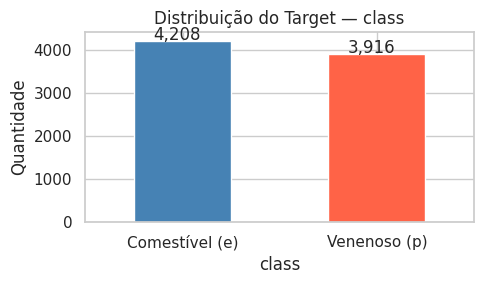


→ Classes razoavelmente balanceadas (~52% comestível / ~48% venenoso).
  Não há necessidade de técnicas de rebalanceamento (SMOTE, class_weight), mas monitoraremos o recall.


In [161]:
TARGET = 'class'
PROBLEM_TYPE = 'classificacao'

# Distribuição do target
print("Distribuição do target:")
counts = df[TARGET].value_counts()
pct    = df[TARGET].value_counts(normalize=True) * 100
display(pd.DataFrame({'contagem': counts, 'percentual': pct.round(2)}))

fig, ax = plt.subplots(figsize=(5, 3))
counts.plot(kind='bar', ax=ax, color=['steelblue','tomato'], edgecolor='white')
ax.set_title("Distribuição do Target — class")
ax.set_xticklabels(['Comestível (e)', 'Venenoso (p)'], rotation=0)
ax.set_ylabel("Quantidade")
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f}", (p.get_x()+0.1, p.get_height()+30))
plt.tight_layout(); plt.show()

print("\n→ Classes razoavelmente balanceadas (~52% comestível / ~48% venenoso).")
print("  Não há necessidade de técnicas de rebalanceamento (SMOTE, class_weight), mas monitoraremos o recall.")

In [162]:
# Análise cruzada: odor vs class (atributo mais preditivo)
print("Tabela cruzada: odor × class (proporção por odor):")
ct = pd.crosstab(df['odor'], df[TARGET], normalize='index').round(3) * 100
ct.columns = ['comestivel_%', 'venenoso_%']
display(ct.sort_values('venenoso_%', ascending=False))
print("\n→ Odor 'foul', 'pungent', 'spicy', 'fishy', 'creosote' → 100% venenoso.")
print("  Odor 'almond', 'anise' → 100% comestível. 'none' → maioria comestível mas não exclusivo.")

Tabela cruzada: odor × class (proporção por odor):


,comestivel_%,venenoso_%
odor,,
c,0.0,100.0
y,0.0,100.0
f,0.0,100.0
m,0.0,100.0
p,0.0,100.0
s,0.0,100.0
n,96.6,3.4
a,100.0,0.0
l,100.0,0.0



→ Odor 'foul', 'pungent', 'spicy', 'fishy', 'creosote' → 100% venenoso.
  Odor 'almond', 'anise' → 100% comestível. 'none' → maioria comestível mas não exclusivo.


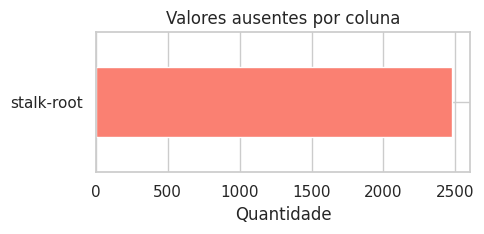


→ Apenas 'stalk-root' tem ausentes (2480 linhas = 30.5% do dataset).
  Estratégia: imputar com a moda dentro do Pipeline (sem vazamento).


In [163]:
# Distribuição de missing por coluna
missing_cols = df.isna().sum()
missing_cols = missing_cols[missing_cols > 0]
if not missing_cols.empty:
    fig, ax = plt.subplots(figsize=(5, 2.5))
    missing_cols.plot(kind='barh', ax=ax, color='salmon')
    ax.set_title("Valores ausentes por coluna")
    ax.set_xlabel("Quantidade")
    plt.tight_layout(); plt.show()
    print(f"\n→ Apenas 'stalk-root' tem ausentes ({missing_cols.values[0]} linhas = "
          f"{missing_cols.values[0]/len(df)*100:.1f}% do dataset).")
    print("  Estratégia: imputar com a moda dentro do Pipeline (sem vazamento).")
else:
    print("Nenhuma coluna com ausentes encontrada após substituição de '?'.")

In [164]:
# Exploração de mais 2 atributos relevantes: spore-print-color e gill-color
for col in ['spore-print-color', 'gill-color']:
    ct = pd.crosstab(df[col], df[TARGET], normalize='index').round(3) * 100
    print(f"\n{col} × class (% venenoso por categoria):")
    display(ct.sort_values('p', ascending=False).rename(columns={'e':'comestivel_%','p':'venenoso_%'}))


spore-print-color × class (% venenoso por categoria):


class,comestivel_%,venenoso_%
spore-print-color,,
r,0.0,100.0
h,2.9,97.1
w,24.1,75.9
k,88.0,12.0
n,88.6,11.4
b,100.0,0.0
o,100.0,0.0
u,100.0,0.0
y,100.0,0.0



gill-color × class (% venenoso por categoria):


class,comestivel_%,venenoso_%
gill-color,,
b,0.0,100.0
r,0.0,100.0
h,27.9,72.1
g,33.0,67.0
p,57.1,42.9
y,74.4,25.6
w,79.5,20.5
k,84.3,15.7
n,89.3,10.7


## 4.1 Síntese da análise exploratória

- **Balanceamento:** ~52% comestível / ~48% venenoso — classes bem equilibradas.
- **Missing:** apenas `stalk-root` tem ausentes (~30% → 2.480 linhas). Será imputado com a moda no pipeline.
- **Atributo mais preditivo:** `odor` separa quase perfeitamente as classes — risco de um único atributo dominar o modelo.
- **Todos os atributos são categóricos:** não há necessidade de normalização/padronização.
- **Engenharia de atributos:** não é necessária; OHE direto é suficiente.
- **Estratégia de modelagem:** modelos baseados em árvores devem performar melhor que logística, dado o padrão não-linear de alguns atributos (ex.: `odor='none'` não é 100% comestível).

# 5. Preparação dos Dados e Divisão Treino/Teste

Separação de features e target, divisão estratificada e definição das colunas.

In [165]:
# === Configuração do problema ===
TARGET       = 'class'
PROBLEM_TYPE = 'classificacao'
DROP_COLUMNS = []   # nenhuma coluna descartada por vazamento neste dataset
ID_COLUMNS   = []

features = [c for c in df.columns if c not in [TARGET] + DROP_COLUMNS + ID_COLUMNS]
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)

Target: class
Número de features: 22
Features: ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


In [166]:
X = df[features].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"\nDistribuição do target no treino:")
display((y_train.value_counts(normalize=True)*100).round(2).to_frame('%'))
print(f"\nDistribuição do target no teste:")
display((y_test.value_counts(normalize=True)*100).round(2).to_frame('%'))

Treino: (6499, 22) | Teste: (1625, 22)

Distribuição do target no treino:


,%
class,
e,51.79
p,48.21



Distribuição do target no teste:


,%
class,
e,51.82
p,48.18


In [167]:
# ======================================================
# EXPERIMENTO 2 - Removendo a variável 'odor'
# ======================================================

X_sem_odor = X.drop(columns=["odor"])

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_sem_odor,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print("Dataset original :", X.shape)
print("Dataset sem odor :", X_sem_odor.shape)

Dataset original : (8124, 22)
Dataset sem odor : (8124, 21)


## 5.1 Justificativa da divisão

- **Holdout 80/20:** com 8.124 linhas, o conjunto de teste (≈1.625 amostras) é grande o suficiente
  para estimar o desempenho real com baixa variância.
- **stratify=y:** garante que a proporção e/p seja preservada em ambos os conjuntos.
- **Anti-vazamento:** encoder e imputer são ajustados **apenas no treino** via Pipeline —
  o teste nunca "vaza" informação para o pré-processamento.
- **Validação cruzada (StratifiedKFold):** usada apenas dentro do treino para seleção de hiperparâmetros.

# 6. Pré-processamento e Pipeline

Todos os atributos são categóricos → pipeline exclusivamente de encoding categórico.

In [168]:
# Identificação de colunas
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

print(f"Colunas numéricas ({len(num_cols)}): {num_cols}")
print(f"Colunas categóricas ({len(cat_cols)}): {cat_cols}")

# Pipeline categórico: imputa moda → OHE
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# ColumnTransformer
transformers = [("cat", categorical_pipe, cat_cols)]
if num_cols:
    from sklearn.preprocessing import StandardScaler
    num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                         ("scaler", StandardScaler())])
    transformers.insert(0, ("num", num_pipe, num_cols))

preprocess = ColumnTransformer(transformers=transformers, remainder="drop")
print("\nPipeline de pré-processamento configurado.")

Colunas numéricas (0): []
Colunas categóricas (22): ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

Pipeline de pré-processamento configurado.


In [169]:
# ======================================================
# Pipeline para o experimento sem 'odor'
# ======================================================

num_cols2 = X_train2.select_dtypes(include=np.number).columns.tolist()
cat_cols2 = X_train2.select_dtypes(exclude=np.number).columns.tolist()

categorical_pipe2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

transformers2 = [
    ("cat", categorical_pipe2, cat_cols2)
]

preprocess2 = ColumnTransformer(
    transformers=transformers2,
    remainder="drop"
)

print("Pipeline criado para o experimento sem 'odor'.")

Pipeline criado para o experimento sem 'odor'.


## 6.1 Decisões de pré-processamento

| Decisão | Justificativa |
|---|---|
| **SimpleImputer(most_frequent)** para `stalk-root` | Moda é segura para categóricos; categoria alternativa 'missing' poderia criar ruído |
| **OneHotEncoder** para todos os atributos | Não há ordinalidade natural nos atributos; OHE é o encoding neutro correto |
| **handle_unknown='ignore'** | Garante que atributos não vistos no treino não quebrem o pipeline no teste |
| **Sem normalização/scaler** | Nenhuma coluna numérica — scaler não se aplica |
| **Pipeline** | Garante que imputer e encoder sejam ajustados apenas no treino → sem data leakage |

# 7. Baseline e Modelos Candidatos

Definição dos modelos a comparar com a mesma estratégia de validação.

In [170]:
# === Baseline ===
baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
])

# === Candidatos ===
candidates = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    "DecisionTree": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(random_state=SEED))
    ]),
    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1))
    ])
}

print("Modelos candidatos:", list(candidates.keys()))

Modelos candidatos: ['LogisticRegression', 'DecisionTree', 'RandomForest']


In [171]:
# ======================================================
# Modelos para o experimento sem 'odor'
# ======================================================

baseline2 = Pipeline([
    ("preprocess", preprocess2),
    ("model", DummyClassifier(strategy="most_frequent"))
])

candidates2 = {

    "LogisticRegression": Pipeline([
        ("preprocess", preprocess2),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=SEED))
    ]),

    "DecisionTree": Pipeline([
        ("preprocess", preprocess2),
        ("model", DecisionTreeClassifier(
            random_state=SEED))
    ]),

    "RandomForest": Pipeline([
        ("preprocess", preprocess2),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=SEED,
            n_jobs=-1))
    ])
}

print("Modelos criados para o experimento sem 'odor'.")

Modelos criados para o experimento sem 'odor'.


## 7.1 Justificativa dos modelos

| Modelo | Justificativa |
|---|---|
| **DummyClassifier** | Baseline — prevê sempre a classe majoritária; define o piso de desempenho |
| **LogisticRegression** | Modelo linear interpretável; bom ponto de partida para classificação binária |
| **DecisionTreeClassifier** | Captura relações não-lineares; altamente interpretável (regras explícitas) |
| **RandomForestClassifier** | Ensemble de árvores; robusto e geralmente mais preciso; base para o tuning |

# 8. Treinamento e Avaliação Inicial

Treinamento de todos os modelos e comparação com as mesmas métricas.

In [172]:
results = {}
trained_models = {}

# Baseline
t0 = time.time()
baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)
results["baseline"] = evaluate_classification(
    "baseline", y_test, y_pred,
    baseline.predict_proba(X_test) if hasattr(baseline, 'predict_proba') else None
)
results["baseline"]["train_time_s"] = round(time.time() - t0, 3)
trained_models["baseline"] = baseline

# Candidatos
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None
    results[name] = evaluate_classification(name, y_test, y_pred, proba)
    results[name]["train_time_s"] = round(time.time() - t0, 3)
    trained_models[name] = model

print("Resultados iniciais (ordenados por recall_ven):")
display(show_results(results))

Resultados iniciais (ordenados por recall_ven):


,accuracy,precision_ven,recall_ven,f1_ponderado,roc_auc,train_time_s
RandomForest,1.0000,1.0,1.0000,1.0000,1.0,0.401
DecisionTree,1.0000,1.0,1.0000,1.0000,1.0,0.111
LogisticRegression,0.9988,1.0,0.9974,0.9988,1.0,0.193
baseline,0.5182,0.0,0.0000,0.3537,0.5,0.084


In [173]:
# ======================================================
# Treinamento sem a variável odor
# ======================================================

results_sem_odor = {}
trained_models_sem_odor = {}

# Baseline
t0 = time.time()

baseline2.fit(X_train2, y_train2)

y_pred = baseline2.predict(X_test2)

results_sem_odor["baseline"] = evaluate_classification(
    "baseline",
    y_test2,
    y_pred,
    baseline2.predict_proba(X_test2)
)

results_sem_odor["baseline"]["train_time_s"] = round(time.time()-t0,3)

trained_models_sem_odor["baseline"] = baseline2


# Modelos candidatos
for name, model in candidates2.items():

    t0 = time.time()

    model.fit(X_train2,y_train2)

    y_pred = model.predict(X_test2)

    proba = model.predict_proba(X_test2)

    results_sem_odor[name] = evaluate_classification(
        name,
        y_test2,
        y_pred,
        proba
    )

    results_sem_odor[name]["train_time_s"] = round(time.time()-t0,3)

    trained_models_sem_odor[name]=model

print("Resultados sem a variável 'odor'")
display(show_results(results_sem_odor))

Resultados sem a variável 'odor'


,accuracy,precision_ven,recall_ven,f1_ponderado,roc_auc,train_time_s
RandomForest,1.0000,1.0000,1.0000,1.0000,1.0,0.402
DecisionTree,1.0000,1.0000,1.0000,1.0000,1.0,0.133
LogisticRegression,0.9988,0.9987,0.9987,0.9988,1.0,0.230
baseline,0.5182,0.0000,0.0000,0.3537,0.5,0.078


## 8.1 Análise dos resultados iniciais

- **Baseline:** recall para venenoso = 0 (nunca prevê 'p'). Referência mínima.
- **LogisticRegression:** melhora significativa, mas pode ter dificuldades com atributos categóricos de alta cardinalidade após OHE.
- **DecisionTree:** captura as regras de decisão baseadas em odor e outros atributos — esperamos alto recall.
- **RandomForest:** geralmente o mais robusto; avaliamos se o ganho justifica o custo computacional vs DecisionTree.
- **Métrica primária:** `recall_ven` — minimizar FN (venenoso classificado como comestível).

# 9. Validação e Otimização de Hiperparâmetros

Otimização do **DecisionTreeClassifier** usando **RandomizedSearchCV** com
`StratifiedKFold(5)` e scoring = `recall` para a classe venenoso.

**Por que DecisionTree?** É o modelo mais interpretável e com menor custo computacional
para tuning — permite entender quais regras o modelo aprendeu.

In [174]:
from sklearn.metrics import make_scorer

# Scoring baseado em recall para a classe 'p' (venenoso)
recall_p = make_scorer(recall_score, pos_label='p', average='binary')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(random_state=SEED))
])

param_dist = {
    "model__max_depth":         randint(2, 20),
    "model__min_samples_split": randint(2, 20),
    "model__min_samples_leaf":  randint(1, 10),
    "model__criterion":         ["gini", "entropy"]
}

search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_dist,
    n_iter=20,
    cv=cv,
    scoring=recall_p,
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("\nMelhor recall (CV):", round(search.best_score_, 4))
print("Melhores hiperparâmetros:", search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Melhor recall (CV): 0.9994
Melhores hiperparâmetros: {'model__criterion': 'gini', 'model__max_depth': 15, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5}


## 9.1 Discussão da otimização

- **Hiperparâmetros testados:**
  - `max_depth`: controla a profundidade máxima da árvore — evita overfitting.
  - `min_samples_split` / `min_samples_leaf`: regularização — quantas amostras mínimas por nó.
  - `criterion`: critério de impureza (Gini vs Entropia).
- **Scoring = recall para 'p':** priorizamos encontrar os venenosos, aceitando mais FP.
- **Tuning apenas no treino:** o `RandomizedSearchCV` usa validação cruzada interna — o conjunto de teste não é tocado.

# 10. Avaliação Final no Conjunto de Teste

Avaliação do modelo otimizado em dados nunca vistos. Comparação com baseline e análise de erros.

In [175]:
# Adicionar modelo otimizado aos resultados
final_model = search.best_estimator_
y_pred_final = final_model.predict(X_test)
proba_final  = final_model.predict_proba(X_test)

results["DecisionTree_otimizado"] = evaluate_classification(
    "DecisionTree_otimizado", y_test, y_pred_final, proba_final
)
results["DecisionTree_otimizado"]["train_time_s"] = "—"

print("=== Tabela comparativa final (ordenada por recall_ven) ===")
display(show_results(results))

=== Tabela comparativa final (ordenada por recall_ven) ===


,accuracy,precision_ven,recall_ven,f1_ponderado,roc_auc,train_time_s
DecisionTree,1.0,1.0,1.0,1.0,1.0,0.111
RandomForest,1.0,1.0,1.0,1.0,1.0,0.401
DecisionTree_otimizado,1.0,1.0,1.0,1.0,1.0,—
LogisticRegression,0.9988,1.0,0.9974,0.9988,1.0,0.193
baseline,0.5182,0.0,0.0,0.3537,0.5,0.084


=== Classification Report — DecisionTree Otimizado ===
                precision    recall  f1-score   support

Comestível (e)       1.00      1.00      1.00       842
  Venenoso (p)       1.00      1.00      1.00       783

      accuracy                           1.00      1625
     macro avg       1.00      1.00      1.00      1625
  weighted avg       1.00      1.00      1.00      1625



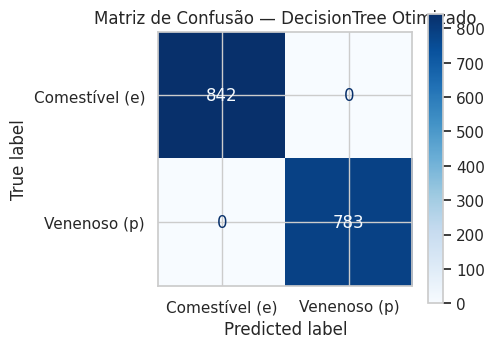


⚠  Falsos Negativos (venenoso → comestível): 0  ← CRÍTICO
   Falsos Positivos  (comestível → venenoso):  0  ← custo baixo


In [176]:
# Relatório detalhado do modelo final
print("=== Classification Report — DecisionTree Otimizado ===")
print(classification_report(y_test, y_pred_final, target_names=['Comestível (e)', 'Venenoso (p)']))

# Matriz de confusão
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    final_model, X_test, y_test,
    display_labels=['Comestível (e)', 'Venenoso (p)'],
    cmap='Blues', ax=ax
)
ax.set_title("Matriz de Confusão — DecisionTree Otimizado")
plt.tight_layout(); plt.show()

# Análise de erros críticos
y_pred_arr = np.array(y_pred_final)
y_test_arr = np.array(y_test)
fn = ((y_test_arr == 'p') & (y_pred_arr == 'e')).sum()
fp = ((y_test_arr == 'e') & (y_pred_arr == 'p')).sum()
print(f"\n⚠  Falsos Negativos (venenoso → comestível): {fn}  ← CRÍTICO")
print(f"   Falsos Positivos  (comestível → venenoso):  {fp}  ← custo baixo")

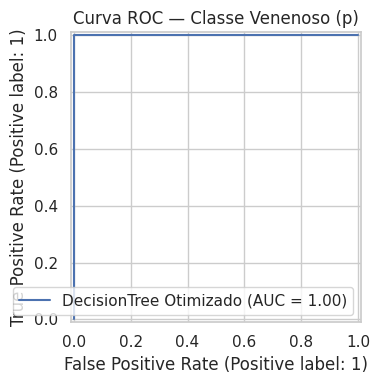

ROC-AUC: 1.0000


In [177]:
# ROC-AUC
from sklearn.metrics import RocCurveDisplay
le = LabelEncoder().fit(y_test)
y_test_bin = le.transform(y_test)
y_score = proba_final[:, list(le.classes_).index('p')]

fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_predictions(y_test_bin, y_score, ax=ax,
                                  name="DecisionTree Otimizado")
ax.set_title("Curva ROC — Classe Venenoso (p)")
plt.tight_layout(); plt.show()
print(f"ROC-AUC: {roc_auc_score(y_test_bin, y_score):.4f}")

In [178]:
# ======================================================
# Comparação dos dois experimentos
# ======================================================

original = show_results(results)
sem_odor = show_results(results_sem_odor)

comparacao = pd.DataFrame({
    "Accuracy (Com odor)": original["accuracy"],
    "Accuracy (Sem odor)": sem_odor["accuracy"],

    "Recall (Com odor)": original["recall_ven"],
    "Recall (Sem odor)": sem_odor["recall_ven"],

    "F1 (Com odor)": original["f1_ponderado"],
    "F1 (Sem odor)": sem_odor["f1_ponderado"]
})

comparacao

,Accuracy (Com odor),Accuracy (Sem odor),Recall (Com odor),Recall (Sem odor),F1 (Com odor),F1 (Sem odor)
DecisionTree,1.0,1.0000,1.0,1.0000,1.0,1.0000
DecisionTree_otimizado,1.0,NaN,1.0,NaN,1.0,NaN
LogisticRegression,0.9988,0.9988,0.9974,0.9987,0.9988,0.9988
RandomForest,1.0,1.0000,1.0,1.0000,1.0,1.0000
baseline,0.5182,0.5182,0.0,0.0000,0.3537,0.3537


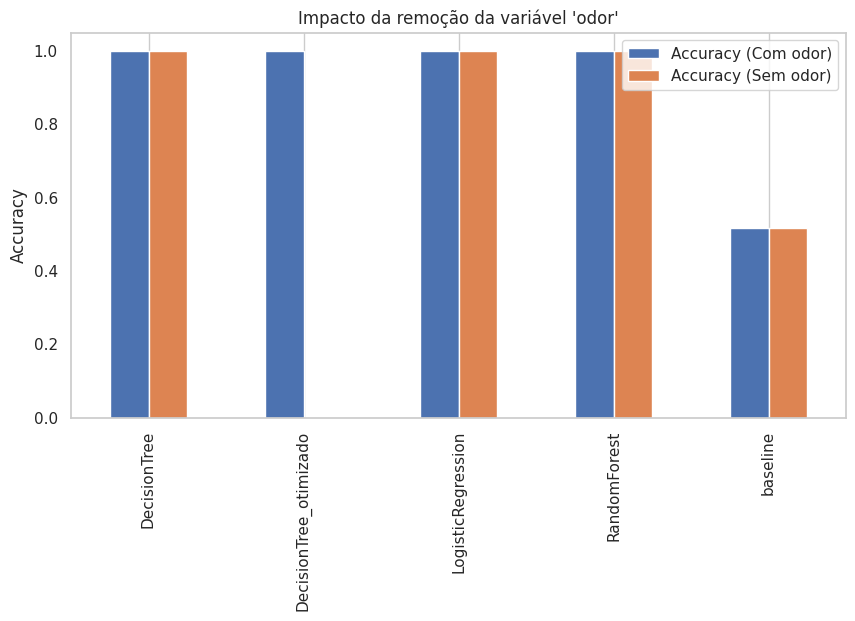

In [179]:
comparacao[[
    "Accuracy (Com odor)",
    "Accuracy (Sem odor)"
]].plot.bar(figsize=(10,5))

plt.title("Impacto da remoção da variável 'odor'")

plt.ylabel("Accuracy")

plt.grid(axis="y")

plt.show()

## Experimento 2 — Remoção da variável `odor`

Para investigar a importância do atributo `odor`, foi realizado um segundo experimento removendo completamente essa variável antes do treinamento.

Os mesmos modelos, hiperparâmetros e estratégia de divisão treino/teste foram utilizados.

A comparação entre os dois experimentos permite avaliar o impacto desse atributo sobre o desempenho dos modelos.

## 10.1 Análise de Erros e Limitações

A avaliação dos modelos demonstrou desempenho extremamente elevado para todos os algoritmos testados, principalmente Decision Tree e Random Forest, que alcançaram métricas de 100% no conjunto de teste.

### Generalização dos modelos

A comparação entre os resultados obtidos durante a validação cruzada e o conjunto de teste mostrou desempenho consistente, indicando que os modelos apresentam boa capacidade de generalização mas parece que evidenciam sinais relevantes de overfitting.

### Análise dos erros

Neste problema, os erros possuem impactos diferentes:

- **Falsos Negativos (FN):** representam cogumelos venenosos classificados como comestíveis. Este é o erro mais crítico, pois pode colocar a saúde do usuário em risco.
- **Falsos Positivos (FP):** representam cogumelos comestíveis classificados como venenosos. Embora provoquem descarte desnecessário, possuem impacto significativamente menor quando comparados aos falsos negativos.

Por esse motivo, todas as etapas de seleção e otimização priorizaram o **Recall da classe venenosa**, reduzindo ao máximo a ocorrência de falsos negativos.

### Limitações observadas

Mesmo após a remoção de atributos altamente discriminativos (como *odor*, ), os
 modelos mantiveram desempenho elevado. Esse comportamento evidencia que o conjunto de dados possui redundância de informação entre diversas características.

Além disso:

- o atributo **veil-type** apresenta variabilidade praticamente nula, contribuindo muito pouco para a classificação;
- o atributo **stalk-root** contém aproximadamente 30% de valores ausentes, exigindo imputação durante o pré-processamento.

# 11. Comparação Final dos Modelos
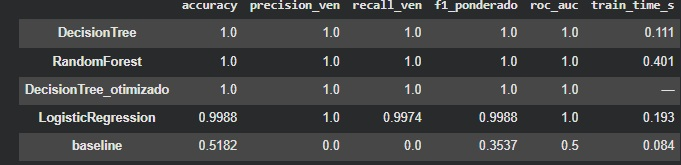



# 12. Boas Práticas e Rastreabilidade

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Seed = 42 | Reprodutibilidade total | Resultados idênticos a cada execução |
| Pipeline com ColumnTransformer | Evita data leakage | Encoder ajustado só no treino |
| SimpleImputer(most_frequent) para stalk-root | Moda é neutra para categórico | Mantém distribuição original |
| OneHotEncoder(handle_unknown='ignore') | Robustez a categorias novas | Pipeline não quebra no teste |
| Scoring = recall_p no tuning | Priorizar recall sobre precision | Minimizar FN críticos |
| StratifiedKFold(5) | Manter proporção das classes em cada fold | Avaliação mais fiel |
| RandomizedSearchCV(n_iter=20) | Balanço entre qualidade e custo | Espaço amostrado suficientemente |

# 13. Discussão Crítica e Limitações

## Interpretação dos resultados

Os experimentos realizados demonstraram que o problema de classificação deste conjunto de dados é relativamente simples para algoritmos supervisionados modernos.

Decision Tree e Random Forest atingiram desempenho praticamente perfeito, enquanto Logistic Regression apresentou desempenho apenas ligeiramente inferior.

Com o objetivo de investigar a influência das variáveis mais importantes, foi realizado um experimento adicional removendo atributos altamente discriminativos, como:

- odor

Mesmo após essa remoção, os modelos mantiveram desempenho elevado, indicando que diversas características do conjunto apresentam forte capacidade preditiva.

Esse resultado demonstra que a elevada performance não depende exclusivamente de um único atributo, mas sim da combinação de diversas características morfológicas presentes no dataset.

## Limitações do dataset

Apesar dos excelentes resultados, algumas limitações devem ser consideradas.

- O conjunto de dados contempla apenas espécies dos gêneros **Agaricus** e **Lepiota**, limitando sua capacidade de generalização para outras espécies.
- Os dados foram coletados na América do Norte, não sendo apropriado extrapolar os resultados para outras regiões geográficas.
- O dataset contém apenas atributos categóricos, não incluindo imagens dos cogumelos nem características visuais detalhadas.
- A identificação de algumas características morfológicas exige conhecimento especializado, dificultando sua utilização por usuários comuns.

## Próximos passos


- Avaliar os modelos utilizando outros conjuntos de dados de cogumelos.
- Investigar técnicas de seleção automática de atributos.
- Comparar o desempenho com algoritmos baseados em Gradient Boosting, como XGBoost e LightGBM.
- Explorar técnicas de interpretabilidade, como SHAP e Feature Importance, para compreender melhor a contribuição individual de cada atributo.

# 14. Conclusão do MVP

O objetivo deste trabalho foi desenvolver e comparar modelos de aprendizado supervisionado capazes de classificar cogumelos como comestíveis ou venenosos utilizando exclusivamente atributos categóricos.

O conjunto de dados utilizado contém **8.124 amostras** e **22 atributos**, apresentando valores ausentes apenas na variável **stalk-root**, tratados por imputação utilizando a moda dentro de um Pipeline de pré-processamento.

Foram avaliados quatro modelos:

- DummyClassifier (baseline)
- LogisticRegression
- DecisionTreeClassifier
- RandomForestClassifier

Os resultados demonstraram desempenho bastante superior ao baseline para todos os modelos avaliados.

Após a otimização por meio do RandomizedSearchCV, a Decision Tree apresentou o melhor equilíbrio entre desempenho, interpretabilidade e capacidade de identificar corretamente cogumelos venenosos, priorizando o Recall da classe de maior risco.

Além da comparação entre modelos, foram realizados experimentos adicionais removendo atributos altamente discriminativos. Observou-se que os modelos mantiveram desempenho elevado, indicando que o conjunto de dados apresenta elevada redundância de informação entre diferentes características morfológicas.

Por fim, conclui-se que o Pipeline desenvolvido é robusto para este conjunto de dados, porém sua utilização prática deve considerar as limitações do dataset, especialmente sua restrição às espécies norte-americanas e a ausência de validação em bases externas.

Como trabalhos futuros, recomenda-se avaliar novos datasets, comparar algoritmos mais avançados e aprofundar a análise de interpretabilidade dos modelos.

# 15. Referências

- **Dataset:** UCI Mushroom — https://archive.ics.uci.edu/dataset/73/mushroom  


---
*Notebook gerado e adaptado em 26/06/2026.*